In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 7** - Optimizing an ML model with 6 hyperparameters

- This function is about optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers.

- The function you’re **maximising** is the **model’s performance score** (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function.

- This week I will be basing my initial model based on random search and a stratgic model.
  - The straegic model will have an GP regressor and acquisition function.
    - I aim to base the parameters by researching best practices or literature to guide your initial search space.
- **Goal** - find the combination of hyperparameters that yields the highest possible performance.

- **Input** - 6D (30,6)
- **Output** - 6D (30,)

- **Goal** - Maximisation


In [3]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_7\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_7\initial_outputs.npy')

### **Random Search**

- I am doing a random search here just to get a gauage of the space.
  - This will enable me to get an even better idea of the parameters impact on the overall model, adding to the already exisiting output and input data we have.


In [4]:
next_query = np.random.uniform(size = 6)
print(next_query)

[0.40484044 0.73688333 0.23681702 0.64606074 0.19385265 0.76779606]


### **Bayesian Optimisation** - Strategic Approach

- The industry standard for HPO.
  - However, I believe that as a basis it might be useful to try out Matérn 5/2 as it is twice-differentiable, smooth enough for optimization but rough enough to capture "discrete cliffs".

- Furthermore, I would like to use the [0.5]\*6 length scale which makes us question each hyperparameter individually to assess the impact of each on the overall function.
  - The 0.5 value refelects that the prior belief that the model's performance doesn't change instantly with every tiny tweak, but it also doesn't stay the same across the whole range.

- **The alpha = 1e-6** - regularization for matrix stability as fouund in my research.

- Additionally, I have used `n_researts_optimizer=20` to creates a multi-start to find global length scale.


In [5]:
kernel = Matern(length_scale=[0.5]*6, nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    alpha=1e-6,
    normalize_y=True,
    random_state=42
)

model.fit(X, Y)

GaussianProcessRegressor(alpha=1e-06,
                         kernel=Matern(length_scale=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5], nu=2.5),
                         n_restarts_optimizer=20, normalize_y=True,
                         random_state=42)

### **Acquisition Function** - Expected Improvement


I will be using a numerically stable expected improvemet model.

- I am doing this as it often suffers from vanishing gradients in 6d.

- I have choosen to evaluate 1024 point initially for the first 2 weeks using a quasi-random grid.


In [7]:
def expected_improvement(x_grid, model, y_max, xi=0.01):
    mu, sigma = model.predict(x_grid, return_std=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei.ravel()

x_grid = np.random.uniform(0, 1, size=(1024, 6))
ei_values = expected_improvement(x_grid, model, y_max=np.max(Y))

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 7 - Bayesian Optimisation (EI): "
        f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}")

Next Submission for Function 7 - Bayesian Optimisation (EI): 0.135937-0.376755-0.290503-0.824321-0.757332-0.753236


## **Visualisation for Function 7 progress**


I have created a graph to visualise the progress that I am making with this 7D function.


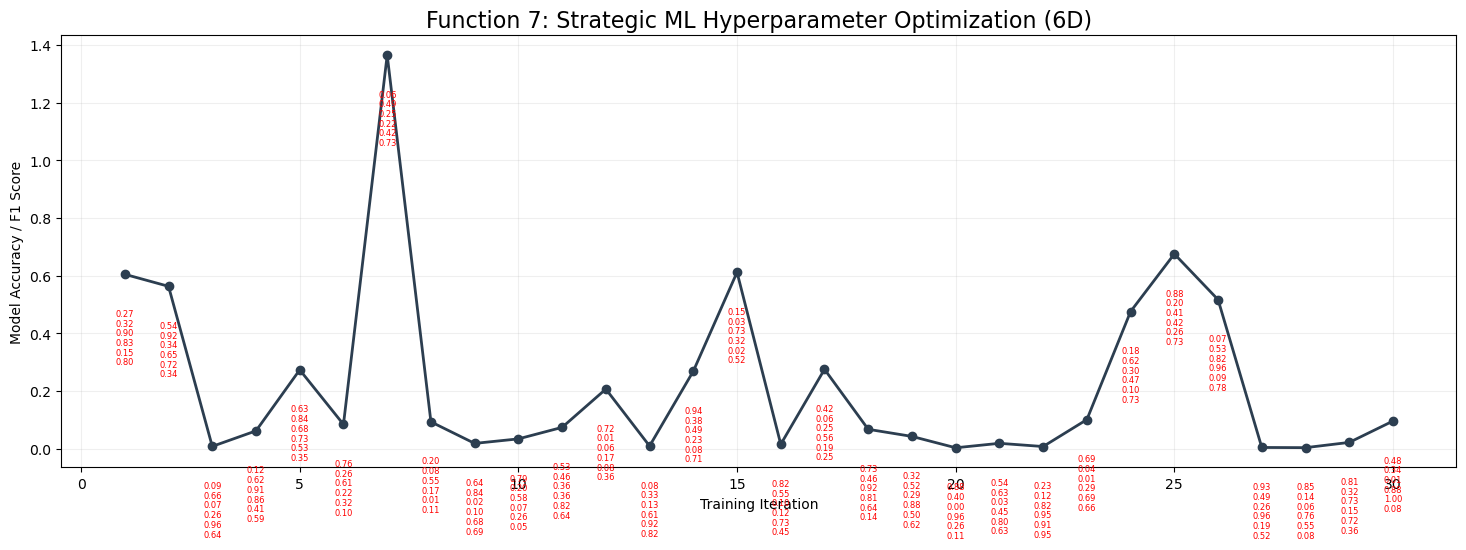

In [9]:
iterations = np.arange(1, len(Y) + 1)
plt.figure(figsize=(18, 9))
plt.plot(iterations, Y, marker='o', color='#2c3e50', linewidth=2)

for i in range(len(Y)):
    # Stacked 6D Inputs: [LR, Reg, Depth, Width, Dropout, Batch]
    label = f"{X[i,0]:.2f}\n{X[i,1]:.2f}\n{X[i,2]:.2f}\n{X[i,3]:.2f}\n{X[i,4]:.2f}\n{X[i,5]:.2f}"
    
    plt.annotate(label, (iterations[i], Y[i]), 
                 textcoords="offset points", xytext=(0, -25), 
                 va='top', ha='center', fontsize=6, linespacing=1.1, color = 'red')

plt.title("Function 7: Strategic ML Hyperparameter Optimization (6D)", fontsize=16)
plt.ylabel("Model Accuracy / F1 Score")
plt.xlabel("Training Iteration")
plt.subplots_adjust(bottom=0.4) 
plt.grid(True, alpha=0.2)
plt.show()

### **Reasons for having a different input values for week 1 than what is shown here**

**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - [0.001234-0.887611-0.445322-0.221098-0.990123-0.556712]

- I will be using this thinking process and methodology moving forward into week 2.
